In [1]:
import pandas as pd
import numpy as np
import uproot as ur
import histlite as hl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# if you install ipympl for interactive plotting, you can activate by uncommenting line below
# %matplotlib widget

In [2]:
run_no = 70 
detectorindex = 0 # HPGE are indexed 0,2,4,6
tof_edges = [-2400, -1300] # region containing prompt events. 
                           # outside this region are early and late events.

# the input file is a .pkl obtained from running preprocessing
inputdatadir = f'/path/to/preprocessed/pklfiles/'
# inputdatadir = f'/home/joey/research/data/TUNL/pkl/raw/'

# the output file(s) are .pkl / .root time-of-flight processed
outputdatadir = f'/path/to/output/tof_processed/pkl_and_rootfiles/'
# outputdatadir = f'/home/joey/research/data/TUNL/roottesting/'

inputfname = f'SSA{run_no}.pkl'
outputfname = f'SSA{run_no}_HPGE{detectorindex}_{np.abs(tof_edges[0])}_{np.abs(tof_edges[1])}'
preprocess_df = pd.read_pickle(inputdatadir+inputfname)

In [3]:
# this cell labels and corrects the TOF data from the preprocessed dataframe.

TOF_df = pd.DataFrame()

# the range of TOF values is [-4096, 0]
daqcode=4096



def tof_daqcode_shift(arr): 
    '''
    some TOF values get offset by integer multiples of 4096, this bring them
    back into range of [-4096,0].
    
    input:
    arr - uncorrected TOF values
    output:
    arrcopy - corrected TOF values
    
    '''
    arrcopy = np.copy(arr)
    for i in [1,2,3,4]: # doing 4 bands is fine for this data, can add more if necessary.
        arrcopy[np.logical_and(arrcopy < -i*daqcode, arrcopy >= -(i+1)*daqcode)] += i*daqcode
    return arrcopy

def tof_prompt_indices(arr):
    indices = np.logical_and(arr <= tof_edges[1], arr >= tof_edges[0]) # includes edge points
    return indices

def tof_late_indices(arr):
    indices = arr > tof_edges[1]
    return indices
    
def tof_early_indices(arr):
    indices = arr < tof_edges[0]
    return indices
    
# for a given detector, NaN events are those that hit the other detectors, so drop them
TOF_df['TOFraw'] = (preprocess_df[f'channel_time[{detectorindex}]']-preprocess_df['trigger_time[0]']).dropna()

# these positive TOF events are present before / after correction of daq code glitch
# for now we are dropping them from the analysis
npos = TOF_df['TOFraw'][TOF_df['TOFraw'] > 0].size
print(f'{TOF_df["TOFraw"].size} hits at the detector')
print(f'there are {npos} events with positive TOF. These are being dropped from processing.')

# remove the positive TOF events
unphysical_indices = TOF_df['TOFraw'][TOF_df['TOFraw']>0].index
TOF_df.drop(unphysical_indices, inplace=True)

# get indices left over after initial cuts (removing NaN and positive TOF), 
# then create column with those amplitudes
TOF_df['amplitude'] = preprocess_df[f'amplitude[{detectorindex}]'][TOF_df.index]
# tofdf.amplitude.isnull().sum() # i beieve NaN removed when we cut on the time of flight, can double check here


# correct daq code offset glitch
TOF_df['TOF'] = tof_daqcode_shift(np.array(TOF_df['TOFraw']))


# label good, early, late
TOF_df['TOFlabel'] = 'good'
TOF_df.loc[tof_early_indices(np.array(TOF_df['TOF'])), 'TOFlabel'] = 'early'
TOF_df.loc[tof_late_indices(np.array(TOF_df['TOF'])), 'TOFlabel'] = 'late'

htof_spectrum = hl.hist(np.array(TOF_df['TOFraw']), bins=1000)
htof_spectrum_corrected = hl.hist(TOF_df['TOF'], bins=htof_spectrum.bins)

3867060 hits at the detector
there are 12698 events with positive TOF. These are being dropped from processing.


In [9]:
# save a rootfile with amplitudes + TOF values for early, good, late events
rf = outputdatadir+outputfname+'.root'
with ur.recreate(rf) as file: # file is a TDirectory object
    for tofval in ['early', 'late', 'good']:
        file.mktree(tofval, {'amplitude': TOF_df['amplitude'][TOF_df['TOFlabel']==tofval].to_numpy(),
                             'TOF': TOF_df['TOF'][TOF_df['TOFlabel']==tofval].to_numpy()})
    file['TOF_info'] =  {'edges': [tof_edges[0], tof_edges[1]]}

In [ ]:
# save a a .pkl file of the pandas dataframe containing results of TOF processing.
TOF_df.to_pickle(outputdatadir+outputfname+'.pkl')

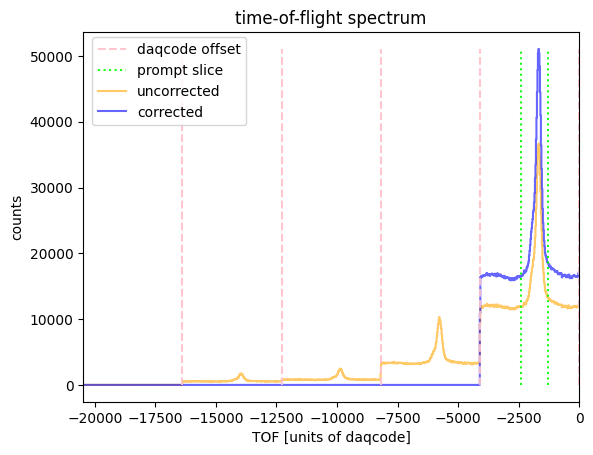

In [10]:
# plot the TOF processing result.

f,a = plt.subplots(1,1)
hl.plot1d(a, htof_spectrum, label='uncorrected', color='orange', alpha=0.6)
hl.plot1d(a, htof_spectrum_corrected, label='corrected', color='blue', alpha=0.6)

maxcounts = np.max(htof_spectrum_corrected.values)
for i, x in enumerate([-daqcode*j for j in range(5)]):
    if i==0:
        label='daqcode offset'
    else:
        label=None
    
    a.plot([x,x],[0,maxcounts], color='pink', linestyle='--', alpha=0.9, label=label)
    
    # use this to plot the tof cut on all bands. when I check on 8MeV data, the peaks lined up as expected in each band.
    # for k,t in enumerate(tof_edges):
        
    #     if i==0 and k==0:
    #         label='prompt slice'
    #     else:
    #         label=None
            
    #     a.plot([t-i*daqcode,t-i*daqcode],[0,maxcounts], color='lime', linestyle=':', alpha=0.9, label=label)
for k,t in enumerate(tof_edges):
        
        if k==0:
            label='prompt slice'
        else:
            label=None
            
        a.plot([t,t],[0,maxcounts], color='lime', linestyle=':', alpha=0.9, label=label)

a.set_ylabel('counts')
a.set_xlabel('TOF [units of daqcode]')
a.set_title('time-of-flight spectrum')
a.set_xlim(-5*daqcode, 0)
f.legend(bbox_to_anchor=(.38, .87), loc='upper right', borderaxespad=0.)